# Wrangle Act

## 1. Introduciton

**The goal** 

As stated in the Project description, we will 'wrangle WeRateDogs Twitter data to create interesting and trustworthy analyses and visualizations'. 

We will gater the data, assess them and fix the highlighted issues (clean). With a cleaned master data frame, we will produce few insights and a visualization.

For easy reference, the 'Key-Points' of the Project Motivation are here reported.

>**Key Points**
>
>Key points to keep in mind when data wrangling for this project:
>
>* You only want original ratings (no retweets) that have images. Though there are 5000+ tweets in the dataset, not all are dog ratings and some are retweets.
>* Assessing and cleaning the entire dataset completely would require a lot of time, and is not necessary to practice and demonstrate your skills in data wrangling. Therefore, the requirements of this project are only to assess and clean at least 8 quality issues and at least 2 tidiness issues in this dataset.
>* Cleaning includes merging individual pieces of data according to the rules of tidy data.
>* The fact that the rating numerators are greater than the denominators does not need to be cleaned. This unique rating system is a big part of the popularity of WeRateDogs.
>* You do not need to gather the tweets beyond August $1^{st}$, 2017. You can, but note that you won't be able to gather the image predictions for these tweets since you don't have access to the algorithm used.


## 2. Gather

In [1]:
import json, matplotlib.pyplot as plt, numpy as np, os, pandas as pd, requests#, tweepy
from tweepy import OAuthHandler
from timeit import default_timer as timer

%matplotlib inline

We will instantiate all dataframes and collect them into a dictionary for easy reference.

In [2]:
DS=dict()

### 2.1 Gather Twieet Data

#### Twitter API Instantiaiton

In [3]:
# # Query Twitter API for each tweet in the Twitter archive and save JSON in a text file
# # These are hidden to comply with Twitter's API terms and conditions
# consumer_key = 'HIDDEN'
# consumer_secret = 'HIDDEN'
# access_token = 'HIDDEN'
# access_secret = 'HIDDEN'

# auth = OAuthHandler(consumer_key, consumer_secret)
# auth.set_access_token(access_token, access_secret)

# api = tweepy.API(auth, wait_on_rate_limit=True)

# # NOTE TO STUDENT WITH MOBILE VERIFICATION ISSUES:
# # df_1 is a DataFrame with the twitter_archive_enhanced.csv file. You may have to
# # change line 17 to match the name of your DataFrame with twitter_archive_enhanced.csv
# # NOTE TO REVIEWER: this student had mobile verification issues so the following
# # Twitter API code was sent to this student from a Udacity instructor
# # Tweet IDs for which to gather additional data via Twitter's API

#### Load of Twitter IDs

In [4]:
DS['archive'] = pd.read_csv('twitter_archive_enhanced.csv')

In [5]:
print('-> Test sample of first 10 tweet IDs: \n', DS['archive'].tweet_id.values[:10])

-> Test sample of first 10 tweet IDs: 
 [892420643555336193 892177421306343426 891815181378084864
 891689557279858688 891327558926688256 891087950875897856
 890971913173991426 890729181411237888 890609185150312448
 890240255349198849]


#### Twitter API Call

In [6]:
# tweet_ids = DS['archive'].tweet_id.values
# len(tweet_ids)
#
# # Query Twitter's API for JSON data for each tweet ID in the Twitter archive
# count = 0
# fails_dict = {}
# start = timer()
# # Save each tweet's returned JSON as a new line in a .txt file
# with open('tweet_json.txt', 'w') as outfile:
#     # This loop will likely take 20-30 minutes to run because of Twitter's rate limit
#     for tweet_id in tweet_ids:
#         count += 1
#         print(str(count) + ": " + str(tweet_id))
#         try:
#             tweet = api.get_status(tweet_id, tweet_mode='extended')
#             print("Success")
#             json.dump(tweet._json, outfile)
#             outfile.write('\n')
#         except tweepy.TweepError as e:
#             print("Fail")
#             fails_dict[tweet_id] = e
#             pass
# end = timer()
# print(end - start)
# print(fails_dict)

#### Import API Data

For "each tweet's JSON data should be written to its own line", we will now "read this .txt file line by line into a pandas DataFrame".

(From '3. Project Details' Udacity DAND webpage, § 'Gathering Data for this Project', 3.).

In [7]:
column_list = ['created_at', 'id', 'id_str', 'full_text', 'truncated',
       'display_text_range', 'entities', 'extended_entities', 'source',
       'in_reply_to_status_id', 'in_reply_to_status_id_str',
       'in_reply_to_user_id', 'in_reply_to_user_id_str',
       'in_reply_to_screen_name', 'user', 'geo', 'coordinates', 'place',
       'contributors', 'is_quote_status', 'retweet_count', 'favorite_count',
       'favorited', 'retweeted', 'possibly_sensitive',
       'possibly_sensitive_appealable', 'lang', 'retweeted_status',
       'quoted_status_id', 'quoted_status_id_str', 'quoted_status']

DS['api'] = pd.DataFrame(columns = column_list)

with open('tweet_json.txt', encoding='utf-8') as tweet_json:
    for line in tweet_json.readlines():
        record_dict = json.loads(line)
        DS['api'] = DS['api'].append(record_dict, ignore_index=True)
    tweet_json.close()

#Ref.s:
# 1) https://stackoverflow.com/questions/27156216/reading-json-file-line-by-line
# 2) https://pynative.com/python-json-load-and-loads-to-parse-json/
# 3) https://stackoverflow.com/questions/21058935/python-json-loads-shows-valueerror-extra-data
# 4) https://stackoverflow.com/questions/11174024/attributeerrorstr-object-has-no-attribute-read

In [8]:
DS['api'].head()

,created_at,id,id_str,full_text,truncated,display_text_range,entities,extended_entities,source,in_reply_to_status_id,...,favorite_count,favorited,retweeted,possibly_sensitive,possibly_sensitive_appealable,lang,retweeted_status,quoted_status_id,quoted_status_id_str,quoted_status
0,Tue Aug 01 16:23:56 +0000 2017,892420643555336193,892420643555336193,This is Phineas. He's a mystical boy. Only eve...,False,"[0, 85]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 892420639486877696, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",None,...,39467,False,False,False,False,en,NaN,NaN,NaN,NaN
1,Tue Aug 01 00:17:27 +0000 2017,892177421306343426,892177421306343426,This is Tilly. She's just checking pup on you....,False,"[0, 138]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 892177413194625024, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",None,...,33819,False,False,False,False,en,NaN,NaN,NaN,NaN
2,Mon Jul 31 00:18:03 +0000 2017,891815181378084864,891815181378084864,This is Archie. He is a rare Norwegian Pouncin...,False,"[0, 121]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 891815175371796480, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",None,...,25461,False,False,False,False,en,NaN,NaN,NaN,NaN
3,Sun Jul 30 15:58:51 +0000 2017,891689557279858688,891689557279858688,This is Darla. She commenced a snooze mid meal...,False,"[0, 79]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 891689552724799489, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",None,...,42908,False,False,False,False,en,NaN,NaN,NaN,NaN
4,Sat Jul 29 16:00:24 +0000 2017,891327558926688256,891327558926688256,This is Franklin. He would like you to stop ca...,False,"[0, 138]","{'hashtags': [{'text': 'BarkWeek', 'indices': ...","{'media': [{'id': 891327551943041024, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",None,...,41048,False,False,False,False,en,NaN,NaN,NaN,NaN


### 2.2 Gather Image Predictions

#### Requests' HTTPS request

In [9]:
response = requests.get('https://d17h27t6h515a5.cloudfront.net/topher/2017/August/599fd2ad_image-predictions/image-predictions.tsv')

# Ref.: https://requests.readthedocs.io/en/master/user/quickstart/#make-a-request

We can briefly check the objects' content by printing the first 300 characters.

In [10]:
print(str(response.text)[:300])

tweet_id	jpg_url	img_num	p1	p1_conf	p1_dog	p2	p2_conf	p2_dog	p3	p3_conf	p3_dog
666020888022790149	https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg	1	Welsh_springer_spaniel	0.465074	True	collie	0.156665	True	Shetland_sheepdog	0.0614285	True
666029285002620928	https://pbs.twimg.com/media/CT42GRgUYAA5iD


Checking object's encoding:

In [11]:
enc = response.encoding
enc

'utf-8'

We can now save the object into a .tsv file...

In [12]:
filename = 'image_predictions.tsv'

if not os.path.exists(filename):
    with open(filename, 'w', encoding = enc) as file:
        file.write(response.text)
        file.close()

..and load it into a Pandas dataframe.

In [13]:
DS['doglike'] = pd.read_csv(filename, sep = '\t', encoding = enc)

## 3. Assess

So far we have collected the following data sets:

| Position | Description | DF Name     |
| :-: | :-------- | :--- |
| 0 | Enhanced Twitter Archive   | archive |
| 1 | API Call Results | api |
| 2 | Image Predictions for Dog Breeds | doglike |

In [14]:
DS.keys()

dict_keys(['archive', 'api', 'doglike'])

We will now assess each of these data sets visually and programmatically.

### 3.1 Enhanced Twitter Archive

At first, we will inspect a sample and the data types visually.

In [15]:
DS['archive'].sample(5)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
955,751598357617971201,NaN,NaN,2016-07-09 02:06:27 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Toby. A cat got his tongue. 13/10 ador...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/751598357...,13,10,Toby,None,None,None,None
1508,691483041324204033,NaN,NaN,2016-01-25 04:49:38 +0000,"<a href=""http://twitter.com/download/iphone"" r...",When bae says they can't go out but you see th...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/691483041...,5,10,None,None,None,None,None
2293,667152164079423490,NaN,NaN,2015-11-19 01:27:25 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Pipsy. He is a fluffball. Enjoys trave...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/667152164...,12,10,Pipsy,None,None,None,None
618,796177847564038144,NaN,NaN,2016-11-09 02:29:25 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Ruby. She just turned o...,7.961497e+17,4.196984e+09,2016-11-09 00:37:46 +0000,https://twitter.com/dog_rates/status/796149749...,11,10,Ruby,None,None,None,None
70,879008229531029506,NaN,NaN,2017-06-25 16:07:47 +0000,"<a href=""http://twitter.com/download/iphone"" r...",This is Beau. That is Beau's balloon. He takes...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/879008229...,13,10,Beau,None,None,None,None


In [16]:
DS['archive'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2356 entries, 0 to 2355
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2356 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2356 non-null   object 
 4   source                      2356 non-null   object 
 5   text                        2356 non-null   object 
 6   retweeted_status_id         181 non-null    float64
 7   retweeted_status_user_id    181 non-null    float64
 8   retweeted_status_timestamp  181 non-null    object 
 9   expanded_urls               2297 non-null   object 
 10  rating_numerator            2356 non-null   int64  
 11  rating_denominator          2356 non-null   int64  
 12  name                        2356 non-null   object 
 13  doggo                       2356 

In [17]:
DS['archive'][DS['archive'].retweeted_status_id.notnull()].sample(1)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
469,816829038950027264,NaN,NaN,2017-01-05 02:09:53 +0000,"<a href=""http://twitter.com/download/iphone"" r...",RT @dog_rates: This is Betty. She's assisting ...,7.909461e+17,4.196984e+09,2016-10-25 16:00:09 +0000,https://twitter.com/dog_rates/status/790946055...,12,10,Betty,None,None,None,puppo


In [18]:
DS['archive'][DS['archive'].in_reply_to_user_id.notnull()].sample(1)

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
184,856526610513747968,8.558181e+17,4.196984e+09,2017-04-24 15:13:52 +0000,"<a href=""http://twitter.com/download/iphone"" r...","THIS IS CHARLIE, MARK. HE DID JUST WANT TO SAY...",NaN,NaN,NaN,https://twitter.com/dog_rates/status/856526610...,14,10,None,None,None,None,None


In [19]:
type(DS['archive'].timestamp.sample(1).values[0])

str

In [20]:
type(DS['archive'][DS['archive'].retweeted_status_timestamp.notnull()].retweeted_status_timestamp.sample(1).values[0])

str

In [21]:
def showWholeField(DF, column, idx=None, sample=True):
    with pd.option_context('display.max_colwidth', -1):
        if type(idx)==int or type(idx)== str:
            print(DF[column].loc[idx : idx])
        elif sample:
            sample_record = DF[DF[column].notnull()].sample(1).copy()
            print(sample_record[column])#,'\n', sample_record.index.tolist()[0])

#Ref.: https://stackoverflow.com/questions/25351968/how-to-display-full-non-truncated-dataframe-information-in-html-when-convertin

In [22]:
showWholeField(DS['archive'], 'source')

919    <a href="http://twitter.com/download/iphone" rel="nofollow">Twitter for iPhone</a>
Name: source, dtype: object


In [23]:
showWholeField(DS['archive'], 'text')

307    RT @dog_rates: This is Rory. He's got an interview in a few minutes. Looking spiffy af. Nervous as h*ck tho. 12/10 would hire https://t.co/…
Name: text, dtype: object


In [24]:
showWholeField(DS['archive'], 'expanded_urls', idx = 1315 )

1315    https://twitter.com/dog_rates/status/706681918348251136/photo/1,https://twitter.com/dog_rates/status/706681918348251136/photo/1,https://twitter.com/dog_rates/status/706681918348251136/photo/1
Name: expanded_urls, dtype: object


In [25]:
DS['archive'].query('tweet_id == "786709082849828864"').rating_numerator

695    75
Name: rating_numerator, dtype: int64

In [26]:
showWholeField(DS['archive'].query('tweet_id == "786709082849828864"'), 'text')

695    This is Logan, the Chow who lived. He solemnly swears he's up to lots of good. H*ckin magical af 9.75/10 https://t.co/yBO5wuqaPS
Name: text, dtype: object


In [27]:
DS['archive']['rating_denominator'].max()

170

In [28]:
DS['archive']['rating_denominator'].min()

0

In [29]:
DS['archive']['name'].sort_values()

1035     Abby
1021     Abby
938       Ace
1933     Acro
1327    Adele
        ...  
1031     very
773      very
1097     very
819      very
1385     very
Name: name, Length: 2356, dtype: object

No NaNs for column 'name', but 'very' does not look like a name.

In [30]:
DS['archive'][DS['archive']['name'].isnull() == True]

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo


No Nans.

Check:

In [31]:
with pd.option_context('display.max_colwidth', -1):
    print(DS['archive'].query('name == "very"')['expanded_urls'])

773     https://twitter.com/dog_rates/status/700747788515020802/photo/1
819     https://twitter.com/dog_rates/status/770655142660169732/photo/1
1031    https://twitter.com/dog_rates/status/745422732645535745/photo/1
1097    https://twitter.com/dog_rates/status/736225175608430592/photo/1
1385    https://twitter.com/dog_rates/status/700747788515020802/photo/1
Name: expanded_urls, dtype: object


It looks like that few words, like 'very', have been picked up by mistake, for they follow the string 'This is '.

Let us examine the dog names.

In [32]:
names=DS['archive']['name'].unique().tolist()
names.sort()
names

['Abby',
 'Ace',
 'Acro',
 'Adele',
 'Aiden',
 'Aja',
 'Akumi',
 'Al',
 'Albert',
 'Albus',
 'Aldrick',
 'Alejandro',
 'Alexander',
 'Alexanderson',
 'Alf',
 'Alfie',
 'Alfy',
 'Alice',
 'Amber',
 'Ambrose',
 'Amy',
 'Amélie',
 'Anakin',
 'Andru',
 'Andy',
 'Angel',
 'Anna',
 'Anthony',
 'Antony',
 'Apollo',
 'Aqua',
 'Archie',
 'Arlen',
 'Arlo',
 'Arnie',
 'Arnold',
 'Arya',
 'Ash',
 'Asher',
 'Ashleigh',
 'Aspen',
 'Astrid',
 'Atlas',
 'Atticus',
 'Aubie',
 'Augie',
 'Autumn',
 'Ava',
 'Axel',
 'Bailey',
 'Baloo',
 'Balto',
 'Banditt',
 'Banjo',
 'Barclay',
 'Barney',
 'Baron',
 'Barry',
 'Batdog',
 'Bauer',
 'Baxter',
 'Bayley',
 'BeBe',
 'Bear',
 'Beau',
 'Beckham',
 'Beebop',
 'Beemo',
 'Bell',
 'Bella',
 'Belle',
 'Ben',
 'Benedict',
 'Benji',
 'Benny',
 'Bentley',
 'Berb',
 'Berkeley',
 'Bernie',
 'Bert',
 'Bertson',
 'Betty',
 'Beya',
 'Biden',
 'Bilbo',
 'Billl',
 'Billy',
 'Binky',
 'Birf',
 'Bisquick',
 'Blakely',
 'Blanket',
 'Blipson',
 'Blitz',
 'Bloo',
 'Bloop',
 'Blu',


These entries must be removed:

In [33]:
noNames = names[names.index('Zuzu')+1:]
noNames.append('None')
noNames

['a',
 'actually',
 'all',
 'an',
 'by',
 'getting',
 'his',
 'incredibly',
 'infuriating',
 'just',
 'life',
 'light',
 'mad',
 'my',
 'not',
 'officially',
 'old',
 'one',
 'quite',
 'space',
 'such',
 'the',
 'this',
 'unacceptable',
 'very',
 'None']

We can check now the values for each WeRateDogs' 'class'.

In [34]:
DS['archive']['doggo'].unique()

array(['None', 'doggo'], dtype=object)

In [35]:
DS['archive']['floofer'].unique()

array(['None', 'floofer'], dtype=object)

In [36]:
DS['archive']['pupper'].unique()

array(['None', 'pupper'], dtype=object)

In [37]:
DS['archive']['puppo'].unique()

array(['None', 'puppo'], dtype=object)

In [38]:
DS['archive'].groupby(["doggo", "floofer", "pupper", "puppo"]).size().reset_index().rename(columns={0: "count"})

,doggo,floofer,pupper,puppo,count
0,None,None,None,None,1976
1,None,None,None,puppo,29
2,None,None,pupper,None,245
3,None,floofer,None,None,9
4,doggo,None,None,None,83
5,doggo,None,None,puppo,1
6,doggo,None,pupper,None,12
7,doggo,floofer,None,None,1


There are 14 records that have more than one classification.

Generally, there is one value per column. This is OK, but these are states of a unique variable - let us call it `dog_stages`. This variabe should display the states of dog(s) within a tweet.

We can sum up here the result of our assessment for the Enhanced Twitter Archive:

**Cleanness**

1. `tweet_id` is of type integer not string (consistency);
2. `in_reply_to_status_id`, `in_reply_to_user_id`, `retweeted_status_id` and `retweeted_status_user_id` are of type float and not string (consistency);
3. `timestamp` and `retweeted_status_timestamp` are of dtype 'string' and should be of [dtype datetime](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dtypes.html) (consistency);
4. `source` looks like a HTML < a > tag. We will extract the source type (consistency);
5. `expanded_urls` has duplicates (consistency);
6. `rating_numerator` contains inaccurate data (accuracy);
7. `rating_denominator` is sometimes not equal to 10, and sometimes even equal to zero (validity, possibly accuracy as well);
8. `name` contains values that are not names (e.g. 'very' and so on; validity).

**Tidiness**

1. Columns `doggo`, `floofer`, `pupper`, `puppo` should be combined into a single column as this is one variable that identify stage of  dog(s) wihin a tweet (rule 1);
2. Generally, all source dataframes have information that is related to a tweeet. Therefore, the dataframes should be merged at the end, in order to combine the information for this observational unit (rule 3).

>#### Recall: messy data (untidy data) - structural issue
>In tidy data:
>1.	Each variable forms a column.
>1.	Each observation forms a row.
>1.	Each type of observational unit forms a table.
 

### 3.2 API Call Results

In [39]:
DS['api'].head()

,created_at,id,id_str,full_text,truncated,display_text_range,entities,extended_entities,source,in_reply_to_status_id,...,favorite_count,favorited,retweeted,possibly_sensitive,possibly_sensitive_appealable,lang,retweeted_status,quoted_status_id,quoted_status_id_str,quoted_status
0,Tue Aug 01 16:23:56 +0000 2017,892420643555336193,892420643555336193,This is Phineas. He's a mystical boy. Only eve...,False,"[0, 85]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 892420639486877696, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",None,...,39467,False,False,False,False,en,NaN,NaN,NaN,NaN
1,Tue Aug 01 00:17:27 +0000 2017,892177421306343426,892177421306343426,This is Tilly. She's just checking pup on you....,False,"[0, 138]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 892177413194625024, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",None,...,33819,False,False,False,False,en,NaN,NaN,NaN,NaN
2,Mon Jul 31 00:18:03 +0000 2017,891815181378084864,891815181378084864,This is Archie. He is a rare Norwegian Pouncin...,False,"[0, 121]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 891815175371796480, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",None,...,25461,False,False,False,False,en,NaN,NaN,NaN,NaN
3,Sun Jul 30 15:58:51 +0000 2017,891689557279858688,891689557279858688,This is Darla. She commenced a snooze mid meal...,False,"[0, 79]","{'hashtags': [], 'symbols': [], 'user_mentions...","{'media': [{'id': 891689552724799489, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",None,...,42908,False,False,False,False,en,NaN,NaN,NaN,NaN
4,Sat Jul 29 16:00:24 +0000 2017,891327558926688256,891327558926688256,This is Franklin. He would like you to stop ca...,False,"[0, 138]","{'hashtags': [{'text': 'BarkWeek', 'indices': ...","{'media': [{'id': 891327551943041024, 'id_str'...","<a href=""http://twitter.com/download/iphone"" r...",None,...,41048,False,False,False,False,en,NaN,NaN,NaN,NaN


In [40]:
DS['api'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2354 entries, 0 to 2353
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   created_at                     2354 non-null   object
 1   id                             2354 non-null   object
 2   id_str                         2354 non-null   object
 3   full_text                      2354 non-null   object
 4   truncated                      2354 non-null   object
 5   display_text_range             2354 non-null   object
 6   entities                       2354 non-null   object
 7   extended_entities              2073 non-null   object
 8   source                         2354 non-null   object
 9   in_reply_to_status_id          78 non-null     object
 10  in_reply_to_status_id_str      78 non-null     object
 11  in_reply_to_user_id            78 non-null     object
 12  in_reply_to_user_id_str        78 non-null     object
 13  in_

**Cleanness**

1. `id` is redundand. We can just keep `id_str` as `id` (consistency);
2. columns `entities`, `extended_entities`, and `source` have a wrong formatting (validity, consistency);
3. columns `geo`, `coordinated`, and `contributors` have no values at all and should be dropped (completeness).

**Tidiness**

1. `created_at` could be decomposed in 'date' and 'time', at least (rule 1.);
2. `display_text_range` should be split into min and max (rule 1.);
3. columns `entities`, `extended_entities`, and `source` should be mved to new tables (rule 3.).

Later on we will consider just `retweet_count`, and `favorite_count` for tweet IDs contained in the trimmed version of the Enhanced Twitter Archive. 

For this reason, we will inspect just these two columns in detail.

In [41]:
DS['api'].retweet_count

0       8853
1       6514
2       4328
3       8964
4       9774
        ... 
2349      41
2350     147
2351      47
2352      48
2353     532
Name: retweet_count, Length: 2354, dtype: object

In [42]:
DS['api'].favorite_count

0       39467
1       33819
2       25461
3       42908
4       41048
        ...  
2349      111
2350      311
2351      128
2352      132
2353     2535
Name: favorite_count, Length: 2354, dtype: object

In [43]:
DS['api'][DS['api'].retweet_count.isnull()==True]

,created_at,id,id_str,full_text,truncated,display_text_range,entities,extended_entities,source,in_reply_to_status_id,...,favorite_count,favorited,retweeted,possibly_sensitive,possibly_sensitive_appealable,lang,retweeted_status,quoted_status_id,quoted_status_id_str,quoted_status


In [44]:
DS['api'][DS['api'].favorite_count.isnull()==True]

,created_at,id,id_str,full_text,truncated,display_text_range,entities,extended_entities,source,in_reply_to_status_id,...,favorite_count,favorited,retweeted,possibly_sensitive,possibly_sensitive_appealable,lang,retweeted_status,quoted_status_id,quoted_status_id_str,quoted_status


No NaNs.

In [45]:
DS['api'][['id', 'retweet_count']][DS['api']['id'].duplicated()]

,id,retweet_count


In [46]:
DS['api'][['id', 'favorite_count']][DS['api']['id'].duplicated()]

,id,favorite_count


No duplicates.

For both columns, we can just highlight the following issue.

**Cleanness**

1. Data tyes of columns `favorite_count` and `retweet_count` should be int.

### 3.3 Image Predictions for Dog Breeds

In [47]:
DS['doglike'].head()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


In [48]:
DS['doglike'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  2075 non-null   int64  
 1   jpg_url   2075 non-null   object 
 2   img_num   2075 non-null   int64  
 3   p1        2075 non-null   object 
 4   p1_conf   2075 non-null   float64
 5   p1_dog    2075 non-null   bool   
 6   p2        2075 non-null   object 
 7   p2_conf   2075 non-null   float64
 8   p2_dog    2075 non-null   bool   
 9   p3        2075 non-null   object 
 10  p3_conf   2075 non-null   float64
 11  p3_dog    2075 non-null   bool   
dtypes: bool(3), float64(3), int64(2), object(4)
memory usage: 152.1+ KB


In [49]:
DS['doglike']['tweet_id'][DS['doglike'].tweet_id.duplicated()==True].count()

0

In [50]:
type(DS['doglike']['tweet_id'].head(1)[0])

numpy.int64

Sample scan for `jpg_url`:

In [51]:
DS['doglike'].jpg_url.sample(10)

304     https://pbs.twimg.com/media/CVG2l9jUYAAwg-w.jpg
450     https://pbs.twimg.com/media/CV0oaHFW4AA9Coi.jpg
1438    https://pbs.twimg.com/media/Cr7q1VxWIAA5Nm7.jpg
928     https://pbs.twimg.com/media/CcBwOn0XEAA7bNQ.jpg
1839    https://pbs.twimg.com/media/C59VqMUXEAAzldG.jpg
308     https://pbs.twimg.com/media/CVHG6_AWwAEJf_u.jpg
745     https://pbs.twimg.com/media/CYp4vFrVAAEs9AX.jpg
694     https://pbs.twimg.com/media/CX7qIcdWcAELJ7N.jpg
722     https://pbs.twimg.com/media/CYUsRsbWAAAUt4Y.jpg
1843    https://pbs.twimg.com/media/C6MrOsEXQAENOds.jpg
Name: jpg_url, dtype: object

In [52]:
showWholeField(DS['doglike'], 'jpg_url', idx = 1792)#320)#1733)#1691)

1792    https://pbs.twimg.com/ext_tw_video_thumb/830956118893543424/pu/img/t2G0raF7pDPRMAH5.jpg
Name: jpg_url, dtype: object


It looks like `jpg_url`contains just a single URL to a .jpg file per record only.

In [53]:
DS['doglike'].img_num.unique()

array([1, 4, 2, 3])

In [54]:
df=DS['doglike'].query('(img_num == 1) or (img_num == 2)').sort_values(by='tweet_id')

In [55]:
df.query('tweet_id == 891327558926688256')

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
2070,891327558926688256,https://pbs.twimg.com/media/DF6hr6BUMAAzZgT.jpg,2,basset,0.555712,True,English_springer,0.22577,True,German_short-haired_pointer,0.175219,True


Only one image for each tweet ID.

In [56]:
breeds = []

In [57]:
breeds += DS['doglike'][DS['doglike'].p1_dog==True].p1.unique().tolist()

In [58]:
breeds += DS['doglike'][DS['doglike'].p2_dog==True].p2.unique().tolist()

In [59]:
breeds += DS['doglike'][DS['doglike'].p3_dog==True].p3.unique().tolist()

In [60]:
breeds = sorted(list(set(breeds)))

In [61]:
breeds

['Afghan_hound',
 'Airedale',
 'American_Staffordshire_terrier',
 'Appenzeller',
 'Australian_terrier',
 'Bedlington_terrier',
 'Bernese_mountain_dog',
 'Blenheim_spaniel',
 'Border_collie',
 'Border_terrier',
 'Boston_bull',
 'Bouvier_des_Flandres',
 'Brabancon_griffon',
 'Brittany_spaniel',
 'Cardigan',
 'Chesapeake_Bay_retriever',
 'Chihuahua',
 'Dandie_Dinmont',
 'Doberman',
 'English_foxhound',
 'English_setter',
 'English_springer',
 'EntleBucher',
 'Eskimo_dog',
 'French_bulldog',
 'German_shepherd',
 'German_short-haired_pointer',
 'Gordon_setter',
 'Great_Dane',
 'Great_Pyrenees',
 'Greater_Swiss_Mountain_dog',
 'Ibizan_hound',
 'Irish_setter',
 'Irish_terrier',
 'Irish_water_spaniel',
 'Irish_wolfhound',
 'Italian_greyhound',
 'Japanese_spaniel',
 'Kerry_blue_terrier',
 'Labrador_retriever',
 'Lakeland_terrier',
 'Leonberg',
 'Lhasa',
 'Maltese_dog',
 'Mexican_hairless',
 'Newfoundland',
 'Norfolk_terrier',
 'Norwegian_elkhound',
 'Norwich_terrier',
 'Old_English_sheepdog',
 

It looks like that the `breed` list contains indeed just dog breed names.

In [62]:
notadog = []

In [63]:
notadog += DS['doglike'][DS['doglike'].p1_dog==False].p1.unique().tolist()

In [64]:
notadog += DS['doglike'][DS['doglike'].p2_dog==False].p2.unique().tolist()

In [65]:
notadog += DS['doglike'][DS['doglike'].p3_dog==False].p3.unique().tolist()

In [66]:
notadog = sorted(list(set(notadog)))

In [67]:
notadog

['African_chameleon',
 'African_crocodile',
 'African_grey',
 'African_hunting_dog',
 'American_alligator',
 'American_black_bear',
 'Angora',
 'Arabian_camel',
 'Arctic_fox',
 'Band_Aid',
 'Christmas_stocking',
 'Egyptian_cat',
 'European_fire_salamander',
 'European_gallinule',
 'French_horn',
 'French_loaf',
 'Gila_monster',
 'Indian_elephant',
 'Loafer',
 'Madagascar_cat',
 'Persian_cat',
 'Siamese_cat',
 'Windsor_tie',
 'abaya',
 'academic_gown',
 'accordion',
 'acorn',
 'acorn_squash',
 'agama',
 'alp',
 'apron',
 'armadillo',
 'ashcan',
 'assault_rifle',
 'axolotl',
 'badger',
 'bagel',
 'bakery',
 'balance_beam',
 'bald_eagle',
 'balloon',
 'ballplayer',
 'banana',
 'banded_gecko',
 'bannister',
 'barbell',
 'barber_chair',
 'barbershop',
 'barracouta',
 'barrel',
 'barrow',
 'basketball',
 'bassinet',
 'bath_towel',
 'bathing_cap',
 'bathtub',
 'beach_wagon',
 'beacon',
 'bearskin',
 'beaver',
 'bee_eater',
 'bell_cote',
 'bib',
 'bighorn',
 'binder',
 'binoculars',
 'birdhous

The `notadog` list looks good as well. 

We could make sure that entry 'cardigan' is not related to a [Cardigan Welsh Corgi](https://en.wikipedia.org/wiki/Cardigan_Welsh_Corgi):

In [68]:
DS['doglike'][DS['doglike'].p2 == 'cardigan'].index.values[0]

233

In [69]:
showWholeField(DS['doglike'], 'jpg_url', idx = 233 )

233    https://pbs.twimg.com/media/CU3P82RWEAAIVrE.jpg
Name: jpg_url, dtype: object


All right - it does not seem to be the case.

**Cleanness**

1. `tweet_id`s should be transformed into strings.

**Tidiness**

No issues.

## 4. Clean

### 4.0 Trim

#### 4.0.1 Trim of the Enhanced Twitter Archive

Before assessment, we can trim the Enhanced Twitter Archive according to the relevant 'key points': 
* You only want original ratings (no retweets)...
* ...that have images.
* You do not need to gather the tweets beyond August $1^{st}$, 2017.

**Point 1)**  First, we will filter for original tweets (no retweet). 

In doing so, we select twitter IDs with no 'retweeted_status_id'.

In [70]:
originalTweets = DS['archive'][DS['archive'].retweeted_status_id.isnull()].copy()

In [71]:
originalTweets.reset_index(drop=True, inplace=True)

# Ref.: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.reset_index.html

In [72]:
originalTweets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2175 entries, 0 to 2174
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    2175 non-null   int64  
 1   in_reply_to_status_id       78 non-null     float64
 2   in_reply_to_user_id         78 non-null     float64
 3   timestamp                   2175 non-null   object 
 4   source                      2175 non-null   object 
 5   text                        2175 non-null   object 
 6   retweeted_status_id         0 non-null      float64
 7   retweeted_status_user_id    0 non-null      float64
 8   retweeted_status_timestamp  0 non-null      object 
 9   expanded_urls               2117 non-null   object 
 10  rating_numerator            2175 non-null   int64  
 11  rating_denominator          2175 non-null   int64  
 12  name                        2175 non-null   object 
 13  doggo                       2175 

**Point 2)** We will now keep tweets with images only, by assessing the field 'expanded_urls' - $i.e.$ by checking if the 'expanded_urls' contains the 'tweet_id'.

In [73]:
showWholeField(originalTweets, 'expanded_urls', idx = 0)

0    https://twitter.com/dog_rates/status/892420643555336193/photo/1
Name: expanded_urls, dtype: object


In [74]:
tw_l = []
for index in originalTweets.index.tolist():
    if str(originalTweets.loc[index].tweet_id) in str(originalTweets.loc[index].expanded_urls):
        tw_l.append(index)

#Ref.: https://stackoverflow.com/questions/5319922/python-check-if-word-is-in-a-string

In [75]:
originalTweets_withPic = originalTweets[originalTweets.index.isin(tw_l)]

#Ref: https://cmdlinetips.com/2018/02/how-to-subset-pandas-dataframe-based-on-values-of-a-column/

In [76]:
originalTweets_withPic.reset_index(drop=True, inplace=True)

In [77]:
originalTweets_withPic.shape[0]


1994

We have found 1994 original tweets with photo.

**Point 3)** We can now check the most recent timestamp and eventually get rid of tweets posted after August 1$^{st}$, 2017.

In [78]:
originalTweets_withPic.sort_values(by=['timestamp'], ascending=False).head(1).timestamp

# Ref.: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sort_values.html

0    2017-08-01 16:23:56 +0000
Name: timestamp, dtype: object

All right - we do not have tweets posted after August 1$^{st}$, 2017.

 We will now add this dataset into our collection.

In [79]:
DS['archive_trimmed'] = originalTweets_withPic

#### 4.0.2 Trim of the API Call Results

We will consider `retweet_count`, and `favorite_count` for tweet `id`s contained in the latest version of the Enhanced Twitter Archive.

First, we check the data type of `tweet_id` in 'archive_trimmed', so that we can filter on the appropriate `id` column.

In [80]:
type(DS['archive_trimmed'].tweet_id.tolist()[0])

int

In [81]:
api_trimmed = DS['api'][DS['api'].id.isin(DS['archive_trimmed'].tweet_id.tolist())].copy()

In [82]:
api_trimmed = api_trimmed[['id', 'retweet_count', 'favorite_count']]

# Ref.: https://stackoverflow.com/questions/11285613/selecting-multiple-columns-in-a-pandas-dataframe

In [83]:
api_trimmed.reset_index(drop=True, inplace=True)

In [84]:
api_trimmed

,id,retweet_count,favorite_count
0,892420643555336193,8853,39467
1,892177421306343426,6514,33819
2,891815181378084864,4328,25461
3,891689557279858688,8964,42908
4,891327558926688256,9774,41048
...,...,...,...
1989,666049248165822465,41,111
1990,666044226329800704,147,311
1991,666033412701032449,47,128
1992,666029285002620928,48,132


In [85]:
DS['api_trimmed'] = api_trimmed

#### 4.0.3 Trim of Image Predictions for Dog Breeds

In [86]:
type(DS['doglike'].tweet_id[0])

numpy.int64

In [87]:
doglike_trimmed = DS['doglike'][DS['doglike'].tweet_id.isin(DS['archive_trimmed'].tweet_id.tolist())].copy()

In [88]:
doglike_trimmed.reset_index(drop=True, inplace=True)

In [89]:
doglike_trimmed.head()

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
0,666020888022790149,https://pbs.twimg.com/media/CT4udn0WwAA0aMy.jpg,1,Welsh_springer_spaniel,0.465074,True,collie,0.156665,True,Shetland_sheepdog,0.061428,True
1,666029285002620928,https://pbs.twimg.com/media/CT42GRgUYAA5iDo.jpg,1,redbone,0.506826,True,miniature_pinscher,0.074192,True,Rhodesian_ridgeback,0.072010,True
2,666033412701032449,https://pbs.twimg.com/media/CT4521TWwAEvMyu.jpg,1,German_shepherd,0.596461,True,malinois,0.138584,True,bloodhound,0.116197,True
3,666044226329800704,https://pbs.twimg.com/media/CT5Dr8HUEAA-lEu.jpg,1,Rhodesian_ridgeback,0.408143,True,redbone,0.360687,True,miniature_pinscher,0.222752,True
4,666049248165822465,https://pbs.twimg.com/media/CT5IQmsXIAAKY4A.jpg,1,miniature_pinscher,0.560311,True,Rottweiler,0.243682,True,Doberman,0.154629,True


In [90]:
doglike_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  1994 non-null   int64  
 1   jpg_url   1994 non-null   object 
 2   img_num   1994 non-null   int64  
 3   p1        1994 non-null   object 
 4   p1_conf   1994 non-null   float64
 5   p1_dog    1994 non-null   bool   
 6   p2        1994 non-null   object 
 7   p2_conf   1994 non-null   float64
 8   p2_dog    1994 non-null   bool   
 9   p3        1994 non-null   object 
 10  p3_conf   1994 non-null   float64
 11  p3_dog    1994 non-null   bool   
dtypes: bool(3), float64(3), int64(2), object(4)
memory usage: 146.2+ KB


In [91]:
DS['doglike_trimmed'] = doglike_trimmed

Overview of the datasets:

In [92]:
DS.keys()

dict_keys(['archive', 'api', 'doglike', 'archive_trimmed', 'api_trimmed', 'doglike_trimmed'])

### 4.1 Cleaning of the Enhanced Twitter Archive

#### Identified issues

**Cleanness**

1. `tweet_id` is of type integer not string (consistency);
2. `in_reply_to_status_id`, `in_reply_to_user_id`, `retweeted_status_id` and `retweeted_status_user_id` are of type float and not string (consistency);
3. `timestamp` and `retweeted_status_timestamp` are of dtype 'string' and should be of [dtype datetime](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dtypes.html) (consistency);
4. `source` looks like a HTML < a > tag. We will extract the source type (consistency);
5. `expanded_urls` has duplicates (consistency);
6. `rating_numerator` contains inaccurate data (accuracy);
7. `rating_denominator` is sometimes not equal to 10, and sometimes even equal to zero (validity, possibly accuracy as well);
8. `name` contains values that are not names (e.g. 'very' and so on; validity).

**Tidiness**

1. Columns `doggo`, `floofer`, `pupper`, `puppo` should be combined into a single column as this is one variable that identify stage of  dog(s) wihin a tweet (rule 1);
2. Generally, all source dataframes have information that is related to a tweeet. Therefore, the dataframes should be merged at the end, in order to combine the information for this observational unit (rule 3).

##### Cleanness - 1

**Define**

Transform data type to string.

**Code**

In [93]:
archive_cp = DS['archive_trimmed'].copy()

In [94]:
type(archive_cp.tweet_id.sample(1).values[0])

numpy.int64

In [95]:
archive_cp.tweet_id = archive_cp.tweet_id.astype(str)

**Test**

In [96]:
type(archive_cp.tweet_id.sample(1).values[0])

str

##### Cleanness - 2

**Define**

Transform data type of columns `in_reply_to_status_id`, `in_reply_to_user_id`, `retweeted_status_id` and `retweeted_status_user_id` to string.

In [97]:
archive_cp[archive_cp.in_reply_to_status_id.notnull()==True].head()

,tweet_id,in_reply_to_status_id,in_reply_to_user_id,timestamp,source,text,retweeted_status_id,retweeted_status_user_id,retweeted_status_timestamp,expanded_urls,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
119,863079547188785154,6.671522e+17,4.196984e+09,2017-05-12 17:12:53 +0000,"<a href=""http://twitter.com/download/iphone"" r...",Ladies and gentlemen... I found Pipsy. He may ...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/863079547...,14,10,None,None,None,None,None
146,856526610513747968,8.558181e+17,4.196984e+09,2017-04-24 15:13:52 +0000,"<a href=""http://twitter.com/download/iphone"" r...","THIS IS CHARLIE, MARK. HE DID JUST WANT TO SAY...",NaN,NaN,NaN,https://twitter.com/dog_rates/status/856526610...,14,10,None,None,None,None,None
192,844979544864018432,7.590995e+17,4.196984e+09,2017-03-23 18:29:57 +0000,"<a href=""http://twitter.com/download/iphone"" r...",PUPDATE: I'm proud to announce that Toby is 23...,NaN,NaN,NaN,https://twitter.com/dog_rates/status/844979544...,13,10,None,None,None,None,None
419,802265048156610565,7.331095e+17,4.196984e+09,2016-11-25 21:37:47 +0000,"<a href=""http://twitter.com/download/iphone"" r...","Like doggo, like pupper version 2. Both 11/10 ...",NaN,NaN,NaN,https://twitter.com/dog_rates/status/802265048...,11,10,None,doggo,None,pupper,None
756,746906459439529985,7.468859e+17,4.196984e+09,2016-06-26 03:22:31 +0000,"<a href=""http://twitter.com/download/iphone"" r...","PUPDATE: can't see any. Even if I could, I cou...",NaN,NaN,NaN,https://twitter.com/dog_rates/status/746906459...,0,10,None,None,None,None,None


In [98]:
archive_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    1994 non-null   object 
 1   in_reply_to_status_id       23 non-null     float64
 2   in_reply_to_user_id         23 non-null     float64
 3   timestamp                   1994 non-null   object 
 4   source                      1994 non-null   object 
 5   text                        1994 non-null   object 
 6   retweeted_status_id         0 non-null      float64
 7   retweeted_status_user_id    0 non-null      float64
 8   retweeted_status_timestamp  0 non-null      object 
 9   expanded_urls               1994 non-null   object 
 10  rating_numerator            1994 non-null   int64  
 11  rating_denominator          1994 non-null   int64  
 12  name                        1994 non-null   object 
 13  doggo                       1994 

**Code**

In [99]:
def checkNan(value):
    try:
        if np.isnan(float(value)):
            return np.nan
    except:
        return str(value)

In [100]:
cols = ['in_reply_to_status_id', 'in_reply_to_user_id', 'retweeted_status_id', 'retweeted_status_user_id']

for col in cols:
    archive_cp[col] = archive_cp[col].apply(lambda x: checkNan(x))

**Test**

In [101]:
for col in cols:
    nulls = archive_cp[col].isnull().count()
    non_nulls = archive_cp.shape[0] - nulls
    print('-> ', col,' - non null values: ', non_nulls)

->  in_reply_to_status_id  - non null values:  0
->  in_reply_to_user_id  - non null values:  0
->  retweeted_status_id  - non null values:  0
->  retweeted_status_user_id  - non null values:  0


In [102]:
archive_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   tweet_id                    1994 non-null   object 
 1   in_reply_to_status_id       0 non-null      float64
 2   in_reply_to_user_id         0 non-null      float64
 3   timestamp                   1994 non-null   object 
 4   source                      1994 non-null   object 
 5   text                        1994 non-null   object 
 6   retweeted_status_id         0 non-null      float64
 7   retweeted_status_user_id    0 non-null      float64
 8   retweeted_status_timestamp  0 non-null      object 
 9   expanded_urls               1994 non-null   object 
 10  rating_numerator            1994 non-null   int64  
 11  rating_denominator          1994 non-null   int64  
 12  name                        1994 non-null   object 
 13  doggo                       1994 

Given that these columns do not contain any relevant value, we can drop them.

In [103]:
archive_cp.drop(columns=cols, inplace = True);

In [104]:
archive_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   tweet_id                    1994 non-null   object
 1   timestamp                   1994 non-null   object
 2   source                      1994 non-null   object
 3   text                        1994 non-null   object
 4   retweeted_status_timestamp  0 non-null      object
 5   expanded_urls               1994 non-null   object
 6   rating_numerator            1994 non-null   int64 
 7   rating_denominator          1994 non-null   int64 
 8   name                        1994 non-null   object
 9   doggo                       1994 non-null   object
 10  floofer                     1994 non-null   object
 11  pupper                      1994 non-null   object
 12  puppo                       1994 non-null   object
dtypes: int64(2), object(11)
memory usage: 202.6+ KB


##### Cleanness - 3

**Define**

Transform data type of `timestamp` and `retweeted_status_timestamp` to datetime.

In [105]:
archive_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   tweet_id                    1994 non-null   object
 1   timestamp                   1994 non-null   object
 2   source                      1994 non-null   object
 3   text                        1994 non-null   object
 4   retweeted_status_timestamp  0 non-null      object
 5   expanded_urls               1994 non-null   object
 6   rating_numerator            1994 non-null   int64 
 7   rating_denominator          1994 non-null   int64 
 8   name                        1994 non-null   object
 9   doggo                       1994 non-null   object
 10  floofer                     1994 non-null   object
 11  pupper                      1994 non-null   object
 12  puppo                       1994 non-null   object
dtypes: int64(2), object(11)
memory usage: 202.6+ KB


We can see that the column `retweeted_status_timestamp` has no entries. We will drop this column.

**Code**

In [106]:
archive_cp_dt = archive_cp.copy() 
archive_cp_dt.timestamp = pd.to_datetime(archive_cp.timestamp)
archive_cp_dt.drop(columns=['retweeted_status_timestamp'], inplace = True);

# Ref.: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.to_datetime.html

**Test**

In [107]:
archive_cp_dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   tweet_id            1994 non-null   object             
 1   timestamp           1994 non-null   datetime64[ns, UTC]
 2   source              1994 non-null   object             
 3   text                1994 non-null   object             
 4   expanded_urls       1994 non-null   object             
 5   rating_numerator    1994 non-null   int64              
 6   rating_denominator  1994 non-null   int64              
 7   name                1994 non-null   object             
 8   doggo               1994 non-null   object             
 9   floofer             1994 non-null   object             
 10  pupper              1994 non-null   object             
 11  puppo               1994 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(2

In [108]:
archive_cp.timestamp

0       2017-08-01 16:23:56 +0000
1       2017-08-01 00:17:27 +0000
2       2017-07-31 00:18:03 +0000
3       2017-07-30 15:58:51 +0000
4       2017-07-29 16:00:24 +0000
                  ...            
1989    2015-11-16 00:24:50 +0000
1990    2015-11-16 00:04:52 +0000
1991    2015-11-15 23:21:54 +0000
1992    2015-11-15 23:05:30 +0000
1993    2015-11-15 22:32:08 +0000
Name: timestamp, Length: 1994, dtype: object

In [109]:
archive_cp_dt.timestamp

0      2017-08-01 16:23:56+00:00
1      2017-08-01 00:17:27+00:00
2      2017-07-31 00:18:03+00:00
3      2017-07-30 15:58:51+00:00
4      2017-07-29 16:00:24+00:00
                  ...           
1989   2015-11-16 00:24:50+00:00
1990   2015-11-16 00:04:52+00:00
1991   2015-11-15 23:21:54+00:00
1992   2015-11-15 23:05:30+00:00
1993   2015-11-15 22:32:08+00:00
Name: timestamp, Length: 1994, dtype: datetime64[ns, UTC]

In [110]:
type(archive_cp.timestamp[0])

str

In [111]:
type(archive_cp_dt.timestamp[0])

pandas._libs.tslibs.timestamps.Timestamp

In [112]:
archive_cp = archive_cp_dt

##### Cleanness - 4

**Define**

We will extract the source type from `source`.

In [113]:
archive_cp.source.unique()

array(['<a href="http://twitter.com/download/iphone" rel="nofollow">Twitter for iPhone</a>',
       '<a href="http://twitter.com" rel="nofollow">Twitter Web Client</a>',
       '<a href="https://about.twitter.com/products/tweetdeck" rel="nofollow">TweetDeck</a>'],
      dtype=object)

**Code**

In [114]:
def mapSource(string):
    mapping={'iphone' :'iphone', 'Twitter Web Client' : 'web_client', 'TweetDeck' : 'tweet_deck'}
    return mapping[[key for key in list(mapping.keys()) if key in string][0]]

In [115]:
archive_cp.source = archive_cp.source.apply(lambda x: mapSource(x))

**Test**

In [116]:
archive_cp.source.unique()

array(['iphone', 'web_client', 'tweet_deck'], dtype=object)

##### Cleanness - 5

**Define**

We can see that some values in `expanded_urls` have more than one link.

In [117]:
showWholeField(archive_cp, 'expanded_urls', idx=432)#, idx = 368)

432    https://twitter.com/dog_rates/status/799757965289017345/photo/1,https://twitter.com/dog_rates/status/799757965289017345/photo/1,https://twitter.com/dog_rates/status/799757965289017345/photo/1,https://twitter.com/dog_rates/status/799757965289017345/photo/1
Name: expanded_urls, dtype: object


Actually, it looks like there is only one link, which is repeated.

We will now remove the duplicates. 

**Code**

In [118]:
archive_cp2 = archive_cp.copy()

In [119]:
archive_cp2.expanded_urls = archive_cp2.expanded_urls.apply(lambda x: x.split(',')[0])

We can actually rename the column into `expanded_url`.

In [120]:
archive_cp2.rename(columns = {'expanded_urls':'expanded_url'}, inplace = True) 

**Test**

In [121]:
showWholeField(archive_cp2, 'expanded_url', idx=432)#, idx = 368)

432    https://twitter.com/dog_rates/status/799757965289017345/photo/1
Name: expanded_url, dtype: object


In [122]:
archive_cp = archive_cp2.copy()

##### Cleanness - 6, 7

**Define**

The `rating_numerator` contains inaccurate data (accuracy) and the `rating_denominator` should be equal to 10.

First, we will check the numerator values visually. 

Then, we will try to extract numerators and denominators from the tweet text and compare them with the respective values.

Finally, we will normalize ratings with denominator diferent than 10.

**Code**

In [123]:
numerators=archive_cp.rating_numerator.unique().tolist()
numerators.sort()
numerators

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 24,
 26,
 27,
 44,
 45,
 50,
 60,
 75,
 80,
 84,
 88,
 99,
 121,
 143,
 144,
 165,
 204,
 420,
 1776]

In [124]:
denominators=archive_cp.rating_denominator.unique().tolist()
denominators.sort()
denominators

[2, 7, 10, 11, 20, 40, 50, 70, 80, 90, 110, 120, 130, 150, 170]

Numerators and denominators look both like integers and natural numbers.

In [125]:
archive_cp2 = archive_cp.copy()

In [126]:
ratings = archive_cp2.text.str.extract('((?:\d+\.)?\d+)\/((?:\d+\.)?\d+)', expand=True)
ratings.columns=['t_rating_numerator', 't_rating_denominator']

In [127]:
ratings

,t_rating_numerator,t_rating_denominator
0,13,10
1,13,10
2,12,10
3,13,10
4,12,10
...,...,...
1989,5,10
1990,6,10
1991,9,10
1992,7,10


In [128]:
t_numerators=ratings.t_rating_numerator.unique().tolist()
t_numerators.sort()
t_numerators

['0',
 '1',
 '10',
 '11',
 '11.26',
 '11.27',
 '12',
 '121',
 '13',
 '13.5',
 '14',
 '143',
 '144',
 '165',
 '1776',
 '2',
 '204',
 '24',
 '3',
 '4',
 '420',
 '44',
 '45',
 '5',
 '50',
 '6',
 '60',
 '7',
 '8',
 '80',
 '84',
 '88',
 '9',
 '9.75',
 '99']

In [129]:
t_denominators=ratings.t_rating_denominator.unique().tolist()
t_denominators.sort()
t_denominators

['10',
 '11',
 '110',
 '120',
 '130',
 '150',
 '170',
 '2',
 '20',
 '40',
 '50',
 '7',
 '70',
 '80',
 '90']

In [130]:
archive_cp2['t_rating_numerator'] = np.round(ratings['t_rating_numerator'].astype(float).astype(int))
archive_cp2['t_rating_denominator'] = np.round(ratings['t_rating_denominator'].astype(int))

#Ref.: https://numpy.org/doc/stable/reference/generated/numpy.around.html#numpy.around

In [131]:
type(archive_cp2['t_rating_numerator'].tolist()[0])

int

In [132]:
archive_cp2[['t_rating_numerator', 't_rating_denominator']]

,t_rating_numerator,t_rating_denominator
0,13,10
1,13,10
2,12,10
3,13,10
4,12,10
...,...,...
1989,5,10
1990,6,10
1991,9,10
1992,7,10


In [133]:
archive_cp2.query('(rating_numerator != t_rating_numerator) or (rating_denominator != t_rating_denominator)')

,tweet_id,timestamp,source,text,expanded_url,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo,t_rating_numerator,t_rating_denominator
39,883482846933004288,2017-07-08 00:28:19+00:00,iphone,This is Bella. She hopes her smile made you sm...,https://twitter.com/dog_rates/status/883482846...,5,10,Bella,None,None,None,None,13,10
503,786709082849828864,2016-10-13 23:23:56+00:00,iphone,"This is Logan, the Chow who lived. He solemnly...",https://twitter.com/dog_rates/status/786709082...,75,10,Logan,None,None,None,None,9,10
553,778027034220126208,2016-09-20 00:24:34+00:00,iphone,This is Sophie. She's a Jubilant Bush Pupper. ...,https://twitter.com/dog_rates/status/778027034...,27,10,Sophie,None,None,pupper,None,11,10
1374,680494726643068929,2015-12-25 21:06:00+00:00,iphone,Here we have uncovered an entire battalion of ...,https://twitter.com/dog_rates/status/680494726...,26,10,None,None,None,None,None,11,10


Just numerator mismatch.

We can now clear the numerators.

In [134]:
idxs= archive_cp2.query('(rating_numerator != t_rating_numerator) or (rating_denominator != t_rating_denominator)').index.tolist()

for idx in idxs:
    archive_cp2.loc[idx:idx,'rating_numerator'] = archive_cp2.loc[idx:idx,'t_rating_numerator']

Check:

In [135]:
archive_cp2.query('(rating_numerator != t_rating_numerator) or (rating_denominator != t_rating_denominator)')

,tweet_id,timestamp,source,text,expanded_url,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo,t_rating_numerator,t_rating_denominator


In [136]:
archive_cp2.drop('t_rating_numerator', axis=1, inplace=True)
archive_cp2.drop('t_rating_denominator', axis=1, inplace=True)

We can now adjust the ratings. We will normalize the rating numerator and then substitute the denominator with 10.

In [137]:
archive_cp2['rating_numerator'] = np.round(archive_cp2['rating_numerator']/archive_cp2['rating_denominator'] * 10).astype(int)

In [138]:
archive_cp2.rating_denominator = 10

**Test**

In [139]:
numerators=archive_cp2['rating_numerator'].unique().tolist()
numerators.sort()
numerators

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 34, 420, 1776]

In [140]:
denominators=archive_cp2['rating_denominator'].unique().tolist()
denominators.sort()
denominators

[10]

In [141]:
archive_cp2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   tweet_id            1994 non-null   object             
 1   timestamp           1994 non-null   datetime64[ns, UTC]
 2   source              1994 non-null   object             
 3   text                1994 non-null   object             
 4   expanded_url        1994 non-null   object             
 5   rating_numerator    1994 non-null   int64              
 6   rating_denominator  1994 non-null   int64              
 7   name                1994 non-null   object             
 8   doggo               1994 non-null   object             
 9   floofer             1994 non-null   object             
 10  pupper              1994 non-null   object             
 11  puppo               1994 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(2

In [142]:
archive_cp = archive_cp2.copy()

##### Cleanness - 8

###### Define

Check for name an remove values that are not names from `name`.

In [143]:
showWholeField(archive_cp[archive_cp.name.isin(noNames) == True], 'text', idx =1846)

1846    This is an Irish Rigatoni terrier named Berta. Completely made of rope. No eyes. Quite large. Loves to dance. 10/10 https://t.co/EM5fDykrJg
Name: text, dtype: object


We can see that some records have the actual name following 'named'. We will try to extract this information. If this is not available, we will set NaN.

###### Code

In [144]:
new_names=[]

for value in archive_cp[archive_cp.name.isin(noNames) == True].text.tolist():
    if 'named' in value:
        words=value.split()
        raw_name=words[words.index('named')+1:words.index('named')+2][0]
        if '.' in raw_name:
            new_names.append(raw_name[:-1])
        else:
            new_names.append(raw_name)
    else:
        new_names.append(np.nan)

#print(new_names)

In [145]:
archive_cp2=archive_cp.copy()
index_list = archive_cp2[archive_cp2.name.isin(noNames) == True].index.tolist()

for idx in index_list:
    try:
        if np.isnan(float(new_names[index_list.index(idx)])):
            archive_cp2.loc[idx: idx , 'name'] = np.nan
    except:
        archive_cp2.loc[idx: idx , 'name'] = new_names[index_list.index(idx)]   
        
# Ref.s: 
# 1) https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
# 2) https://stackoverflow.com/questions/52657223/typeerror-ufunc-isnan-not-supported-for-the-input-types-and-the-inputs-could


###### Test

In [146]:
len(archive_cp2[archive_cp2.name.isin(noNames) == True].index.tolist())

0

In [147]:
len(archive_cp[archive_cp.name.isin(noNames) == True].index.tolist())

644

In [148]:
archive_cp2[archive_cp2.name.isnull()!=True]

,tweet_id,timestamp,source,text,expanded_url,rating_numerator,rating_denominator,name,doggo,floofer,pupper,puppo
0,892420643555336193,2017-08-01 16:23:56+00:00,iphone,This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,None,None,None,None
1,892177421306343426,2017-08-01 00:17:27+00:00,iphone,This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,None,None,None,None
2,891815181378084864,2017-07-31 00:18:03+00:00,iphone,This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,None,None,None,None
3,891689557279858688,2017-07-30 15:58:51+00:00,iphone,This is Darla. She commenced a snooze mid meal...,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,None,None,None,None
4,891327558926688256,2017-07-29 16:00:24+00:00,iphone,This is Franklin. He would like you to stop ca...,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...
1953,666691418707132416,2015-11-17 18:56:35+00:00,iphone,This is Christoper. He is a spotted Penne. Can...,https://twitter.com/dog_rates/status/666691418...,8,10,Christoper,None,None,None,None
1955,666644823164719104,2015-11-17 15:51:26+00:00,iphone,This is Jimothy. He is a Botwanian Gouda. Can ...,https://twitter.com/dog_rates/status/666644823...,9,10,Jimothy,None,None,None,None
1956,666454714377183233,2015-11-17 03:16:00+00:00,iphone,I'll name the dogs from now on. This is Kreggo...,https://twitter.com/dog_rates/status/666454714...,10,10,Kreggory,None,None,None,None
1957,666447344410484738,2015-11-17 02:46:43+00:00,iphone,This is Scout. She is a black Downton Abbey. I...,https://twitter.com/dog_rates/status/666447344...,9,10,Scout,None,None,None,None


In [149]:
archive_cp = archive_cp2.copy()

##### Tidiness - 1

**Define**

Columns `doggo`, `floofer`, `pupper`, `puppo` should be combined into a single column as this is one variable that identify stage of  dog(s) wihin a tweet.

We will first map 'None' strings to Numy's NaNs and then concatenate values for each observation and store them into a  new column called `dog_stages`.

**Code**

In [150]:
archive_cp2 = archive_cp.copy()

In [151]:
def noneToNaN(x):
    if x =='None' or pd.isnull(x):
        return ''
    else:
        return x

In [152]:
columns=['doggo', 'floofer', 'pupper', 'puppo']

for column in columns:
    archive_cp2[column] = archive_cp2[column].apply(lambda x: noneToNaN(x))
    print('Column: ', column, '\n', archive_cp2[column].unique())

Column:  doggo 
 ['' 'doggo']
Column:  floofer 
 ['' 'floofer']
Column:  pupper 
 ['' 'pupper']
Column:  puppo 
 ['' 'puppo']


In [153]:
archive_cp2['dog_stages'] = archive_cp2.doggo + archive_cp2.floofer + archive_cp2.pupper + archive_cp2.puppo
archive_cp2.loc[archive_cp2.dog_stages == 'doggopupper', 'dog_stages'] = 'doggo, pupper'
archive_cp2.loc[archive_cp2.dog_stages == 'doggopuppo', 'dog_stages'] = 'doggo, puppo'
archive_cp2.loc[archive_cp2.dog_stages == 'doggofloofer', 'dog_stages'] = 'doggo, floofer'

**Test**

In [154]:
archive_cp2['dog_stages'].unique()

array(['', 'doggo', 'puppo', 'pupper', 'floofer', 'doggo, puppo',
       'doggo, floofer', 'doggo, pupper'], dtype=object)

We can now drop the columns that are not needed anymore.

In [155]:
for column in columns:
    archive_cp2.drop(column, axis = 1, inplace = True)

In [156]:
archive_cp2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   tweet_id            1994 non-null   object             
 1   timestamp           1994 non-null   datetime64[ns, UTC]
 2   source              1994 non-null   object             
 3   text                1994 non-null   object             
 4   expanded_url        1994 non-null   object             
 5   rating_numerator    1994 non-null   int64              
 6   rating_denominator  1994 non-null   int64              
 7   name                1373 non-null   object             
 8   dog_stages          1994 non-null   object             
dtypes: datetime64[ns, UTC](1), int64(2), object(6)
memory usage: 140.3+ KB


In [157]:
archive_cp = archive_cp2.copy()

##### Tidiness - 2

**Define**

Generally, all source dataframes have information that is related to a tweeet. Therefore, the dataframes should be merged at the end, in order to combine the information for this observational unit (rule 3).

We will address this issue in 4.4.

In [158]:
DS['archive_clean'] = archive_cp

### 4.2 Cleaning of the 'API Call Results' Data Set

**Define**

Data tyes of columns `favorite_count` and `retweet_count` should be int.

**Code**

In [159]:
api_trimmed = DS['api_trimmed'].copy()

In [160]:
api_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1994 non-null   object
 1   retweet_count   1994 non-null   object
 2   favorite_count  1994 non-null   object
dtypes: object(3)
memory usage: 46.9+ KB


In [161]:
type(api_trimmed.id[0])

int

In [162]:
api_trimmed.id = api_trimmed.id.astype(str)

In [163]:
api_trimmed.retweet_count = api_trimmed.retweet_count.astype(int)

In [164]:
api_trimmed.favorite_count = api_trimmed.favorite_count.astype(int)

**Test**

In [165]:
api_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1994 non-null   object
 1   retweet_count   1994 non-null   int64 
 2   favorite_count  1994 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 46.9+ KB


In [166]:
DS['api_clean'] = api_trimmed

### 4.3 Cleaning of 'Image Predictions for Dog Breeds'

**Define**

`tweet_id`s should be transformed into strings.

**Code**

In [167]:
doglike = DS['doglike_trimmed'].copy()

In [168]:
doglike[doglike.tweet_id.isnull()==True]

,tweet_id,jpg_url,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog


In [169]:
doglike.tweet_id = doglike.tweet_id.astype(str)

**Test**

In [170]:
doglike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1994 entries, 0 to 1993
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tweet_id  1994 non-null   object 
 1   jpg_url   1994 non-null   object 
 2   img_num   1994 non-null   int64  
 3   p1        1994 non-null   object 
 4   p1_conf   1994 non-null   float64
 5   p1_dog    1994 non-null   bool   
 6   p2        1994 non-null   object 
 7   p2_conf   1994 non-null   float64
 8   p2_dog    1994 non-null   bool   
 9   p3        1994 non-null   object 
 10  p3_conf   1994 non-null   float64
 11  p3_dog    1994 non-null   bool   
dtypes: bool(3), float64(3), int64(1), object(5)
memory usage: 146.2+ KB


In [171]:
type(doglike.sample(1).tweet_id.values[0])

str

In [172]:
DS['doglike_clean'] = doglike

In [173]:
DS.keys()

dict_keys(['archive', 'api', 'doglike', 'archive_trimmed', 'api_trimmed', 'doglike_trimmed', 'archive_clean', 'api_clean', 'doglike_clean'])

### 4.4 Master Data Set

We will now join the datasets into a master one.

In [174]:
master = DS['archive_clean'].set_index('tweet_id')
master = master.join(DS['api_clean'].set_index('id'), how='inner')
master = master.join(DS['doglike_clean'].set_index('tweet_id'), how='inner')

#Ref.: https://pandas.pydata.org/pandas-docs/stable/user_guide/merging.html

In [175]:
master.index.name = 'tweet_id'
master.head()

#Ref: https://stackoverflow.com/questions/18022845/pandas-index-column-title-or-name

,timestamp,source,text,expanded_url,rating_numerator,rating_denominator,name,dog_stages,retweet_count,favorite_count,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
tweet_id,,,,,,,,,,,,,,,,,,,,,
892420643555336193,2017-08-01 16:23:56+00:00,iphone,This is Phineas. He's a mystical boy. Only eve...,https://twitter.com/dog_rates/status/892420643...,13,10,Phineas,,8853,39467,...,1,orange,0.097049,False,bagel,0.085851,False,banana,0.076110,False
892177421306343426,2017-08-01 00:17:27+00:00,iphone,This is Tilly. She's just checking pup on you....,https://twitter.com/dog_rates/status/892177421...,13,10,Tilly,,6514,33819,...,1,Chihuahua,0.323581,True,Pekinese,0.090647,True,papillon,0.068957,True
891815181378084864,2017-07-31 00:18:03+00:00,iphone,This is Archie. He is a rare Norwegian Pouncin...,https://twitter.com/dog_rates/status/891815181...,12,10,Archie,,4328,25461,...,1,Chihuahua,0.716012,True,malamute,0.078253,True,kelpie,0.031379,True
891689557279858688,2017-07-30 15:58:51+00:00,iphone,This is Darla. She commenced a snooze mid meal...,https://twitter.com/dog_rates/status/891689557...,13,10,Darla,,8964,42908,...,1,paper_towel,0.170278,False,Labrador_retriever,0.168086,True,spatula,0.040836,False
891327558926688256,2017-07-29 16:00:24+00:00,iphone,This is Franklin. He would like you to stop ca...,https://twitter.com/dog_rates/status/891327558...,12,10,Franklin,,9774,41048,...,2,basset,0.555712,True,English_springer,0.225770,True,German_short-haired_pointer,0.175219,True


In [176]:
master.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1994 entries, 892420643555336193 to 666020888022790149
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   timestamp           1994 non-null   datetime64[ns, UTC]
 1   source              1994 non-null   object             
 2   text                1994 non-null   object             
 3   expanded_url        1994 non-null   object             
 4   rating_numerator    1994 non-null   int64              
 5   rating_denominator  1994 non-null   int64              
 6   name                1373 non-null   object             
 7   dog_stages          1994 non-null   object             
 8   retweet_count       1994 non-null   int64              
 9   favorite_count      1994 non-null   int64              
 10  jpg_url             1994 non-null   object             
 11  img_num             1994 non-null   int64              
 12  p1      

In [177]:
DS['master'] = master

## 5. Store, Analyze, and Visualize

### 5.1 Store

We can now write the the master data set into a .csv file.

We will use the separator '\t' for it is less prone to r/w errors - there may be a comma or a semicolon in the 'text' column, for instance.

In [178]:
DS['master'].to_csv('twitter_archive_master.csv', sep='\t', encoding=enc)

### 5.2 Analyze and Visualize

#### Insight 1 - Top and flop ratings

In [179]:
with pd.option_context('display.max_colwidth', -1):
    max_rating = DS['master']['rating_numerator'].max()
    min_rating = DS['master']['rating_numerator'].min()
    url_max = DS['master'][DS['master']['rating_numerator'] == max_rating]['expanded_url'].values[0]
    url_min = DS['master'][DS['master']['rating_numerator'] == min_rating]['expanded_url'].values[0]
    print('Maximum rating: ', max_rating, '\nURL to tweet: ', url_max, \
         '\nMinumum rating: ', min_rating, '\nURL to tweet: ', url_min)

Maximum rating:  1776 
URL to tweet:  https://twitter.com/dog_rates/status/749981277374128128/photo/1 
Minumum rating:  0 
URL to tweet:  https://twitter.com/dog_rates/status/835152434251116546/photo/1


All right, a patriotic pupper :D
...and ...indeed, February $24^{th}$, 2017 was a Friday!

(The other tweet with rating 0 was not that funny).

In [180]:
showWholeField(DS['master'][DS['master']['rating_numerator'] == min_rating], 'expanded_url', idx='746906459439529985')

tweet_id
746906459439529985    https://twitter.com/dog_rates/status/746906459439529985/photo/1
Name: expanded_url, dtype: object


In [181]:
DS['master'].sort_values(['rating_numerator'], ascending=False).head(3)

,timestamp,source,text,expanded_url,rating_numerator,rating_denominator,name,dog_stages,retweet_count,favorite_count,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
tweet_id,,,,,,,,,,,,,,,,,,,,,
749981277374128128,2016-07-04 15:00:45+00:00,tweet_deck,This is Atticus. He's quite simply America af....,https://twitter.com/dog_rates/status/749981277...,1776,10,Atticus,,2772,5569,...,1,bow_tie,0.533941,False,sunglasses,0.080822,False,sunglass,0.050776,False
670842764863651840,2015-11-29 05:52:33+00:00,iphone,After so many requests... here you go.\n\nGood...,https://twitter.com/dog_rates/status/670842764...,420,10,NaN,,4324,7989,...,1,microphone,0.096063,False,accordion,0.094075,False,drumstick,0.061113,False
810984652412424192,2016-12-19 23:06:23+00:00,iphone,Meet Sam. She smiles 24/7 &amp; secretly aspir...,https://www.gofundme.com/sams-smile,34,10,Sam,,1655,5927,...,1,golden_retriever,0.871342,True,Tibetan_mastiff,0.036708,True,Labrador_retriever,0.025823,True


Second place:

In [182]:
showWholeField(DS['master'], 'expanded_url', idx='670842764863651840')

tweet_id
670842764863651840    https://twitter.com/dog_rates/status/670842764863651840/photo/1
Name: expanded_url, dtype: object


Third place:

In [183]:
showWholeField(DS['master'], 'expanded_url', idx='810984652412424192')

tweet_id
810984652412424192    https://www.gofundme.com/sams-smile
Name: expanded_url, dtype: object


#### Insight 2 - Hotest day

By leveraging on Pandas' Datetime methods, we can group results by date and day name.

In [184]:
record = DS['master'].groupby([DS['master']['timestamp'].dt.date]).count().sort_values(['expanded_url'], ascending=False).head(1)

print('The day with the most new-dog tweets was ', record.index[0].strftime("%d/%m/%Y"),\
      '. \nIn that day, ', record.expanded_url.values[0], ' new dogs with an image were posted and rated.' )

#Ref.s: 
# 1) https://www.pythoncentral.io/how-to-display-the-date-and-time-using-python/
# 2) https://stackoverflow.com/questions/39400115/python-pandas-group-by-date-using-datetime-data

The day with the most new-dog tweets was  28/11/2015 . 
In that day,  26  new dogs with an image were posted and rated.


In [185]:
record

,timestamp,source,text,expanded_url,rating_numerator,rating_denominator,name,dog_stages,retweet_count,favorite_count,...,img_num,p1,p1_conf,p1_dog,p2,p2_conf,p2_dog,p3,p3_conf,p3_dog
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-11-28,26,26,26,26,26,26,19,26,26,26,...,26,26,26,26,26,26,26,26,26,26


#### Insight 3 - Weekdays and Average Rating

In [186]:
DS['master'].groupby(DS['master']['timestamp'].dt.day_name()).mean().sort_values(['rating_numerator'], ascending=False)['rating_numerator']

# Ref.: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.dt.day_name.html#pandas.Series.dt.day_name

timestamp
Monday       15.837920
Sunday       12.011719
Friday       10.699647
Thursday     10.693662
Tuesday      10.613559
Saturday     10.599206
Wednesday    10.451178
Name: rating_numerator, dtype: float64

On average, ratings were higher on mondays and sundays! 

#### Visualization

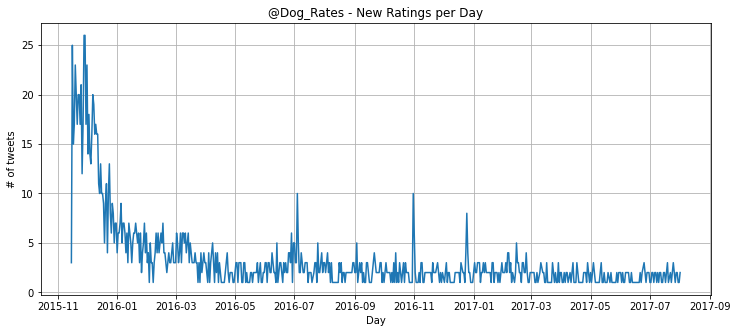

In [187]:
plt.gcf().set_size_inches(12,5)
plt.plot(DS['master'].groupby([DS['master']['timestamp'].dt.date]).expanded_url.count());
plt.title('@Dog_Rates - New Ratings per Day')
plt.xlabel('Day')
plt.ylabel('# of tweets')
plt.grid(True)

Rating activity of `@Dog_Rates` has not been constant over the time lapse under examination.

We clearly see a high-activity period of about two months, where the highest amount of tweets per day has been reached.

Thereafter, the tweet frequency decreased exponentially and stabilized around 2 or 3 tweets per day.

Occasional spikes are clearly visible in July, November and December 2016.